# Project: Temporal Topic Analysis on the CORD19 Dataset
    
## Introduction & Objective
 The COVID-19 Open Research Dataset (CORD-19) represents one of the most significant open-science initiatives in modern history. Curated by the Allen Institute for AI, it contains hundreds of thousands of scholarly articles about COVID-19, SARS-CoV-2, and related coronaviruses. However, the sheer volume of publication—accelerating from dozens per month in early 2020 to thousands per month by mid-year—presents a challenge: How can researchers track the shifting scientific consensus in real-time?
    
## The Goal:
 The objective of this project is to perform Temporal Topic Analysis. Rather than treating the corpus as a static snapshot and perform only NLP processing later fed into unsupervised models, we aim to analyze how scientific discourse evolved focusing on the critical first year of the pandemic (December 2019 – October 2020). We seek to answer questions such as: When did the focus shift from containment to treatment? Did the scientific community prioritize computational models (AI) before biological data was available?

## The Methodology:
 To achieve this, we employ a comparative unsupervised learning approach:
        
* Latent Dirichlet Allocation (LDA): We establish a probabilistic baseline, treating documents as mixtures of topics based on word co-occurrence. We optimize this model using Coherence Scores to find the statistically distinct number of research domains.
        
* BERTopic (Semantic Modeling): We contrast the baseline with a modern transformer-based approach. Utilizing AllenAI SPECTER embeddings (trained specifically on scientific citations), we cluster papers based on semantic meaning rather than just vocabulary overlap.
 And time series aggregation so we can map the dominant topics of over 11,000 papers against their publication dates to generate "River Plots" and heatmaps, visualizing the rise and fall of specific scientific themes.


In [1]:
# === 1. Core Data Handling ===
import pandas as pd
import numpy as np
import os
import re
import string
import json
from tqdm import tqdm

# === 2. Text Preprocessing & NLP ===
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import WordPunctTokenizer
from nltk.stem import WordNetLemmatizer
from collections import Counter
from sklearn.preprocessing import StandardScaler
from sklearn.feature_extraction.text import CountVectorizer

# Vectorization & Embeddings
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from gensim.models import Word2Vec
import torch
from transformers import BertTokenizer, BertModel

# === 3. Machine Learning Tools ===
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MultiLabelBinarizer, MaxAbsScaler
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.multiclass import OneVsRestClassifier

# === 4. Deep Learning (TensorFlow/Keras) ===
import tensorflow as tf
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import (
    Input, Dense, Dropout, BatchNormalization, 
    Flatten, Concatenate, GlobalAveragePooling1D, SimpleRNN
)
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping

# === 5. Multi-Label Evaluation Metrics ===
from sklearn.metrics import (
    f1_score, 
    precision_score, 
    recall_score, 
    hamming_loss, 
    classification_report,
    multilabel_confusion_matrix
)

# === 6. Visualization ===
import matplotlib.pyplot as plt
import seaborn as sns

# Download required NLTK data
nltk.download('stopwords', quiet=True)
nltk.download('wordnet', quiet=True)
nltk.download('omw-1.4', quiet=True)

True

In [ ]:
# ** First option to load and prepare the data for the EDA later performed
# Import your custom modules
import cord19_loader as loader
import cord19_preprocessing as nlp

# Define your path 
DATA_PATH = r"CORD19 Project\cord-19_2020-10-22\2020-10-22"
# Load, merge, and deduplicate
# This calls all the complex logic inside cord19_loader.py
final_df = loader.run_loading_pipeline(DATA_PATH)

# Check the result
print(final_df.head())

In [2]:
# ** Second otpion to load the already processed data for later
# Load the data instead of running the code block above
final_df = pd.read_pickle("cord19_processed.pkl")
final_df

,cord_uid,publish_time,title,abstract,full_text
0,zowp10ts,2005-03-01,Recombination Every Day: Abundant Recombinatio...,Viral recombination can dramatically impact ev...,Recombination Every Day: Abundant Recombinatio...
1,5dk231qs,2005-03-30,Torsional restraint: a new twist on frameshift...,mRNA pseudoknots have a stimulatory function i...,Torsional restraint: a new twist on frameshift...
2,snqdma0s,2005-03-30,Correcting errors in synthetic DNA through con...,Although efficient methods exist to assemble s...,Correcting errors in synthetic DNA through con...
3,1pq6dkl5,2005-03-30,Towards standardization of RNA quality assessm...,While it is universally accepted that intact R...,Towards standardization of RNA quality assessm...
4,754nln40,2005-04-20,Factors affecting translation at the programme...,The ratio between proteins P27 and replicase o...,Factors affecting translation at the programme...
...,...,...,...,...,...
12310,hjtq6wvv,2020-09-09,Regeneration of lung epithelial cells by Fulle...,Acute respiratory distress syndrome (ARDS) inv...,Regeneration of lung epithelial cells by Fulle...
12311,d55wjar0,2020-08-24,Physical Activity for Oncological Patients in ...,Whereas the coronavirus disease (COVID-19) sto...,Physical Activity for Oncological Patients in ...
12312,iciaa829,2005-12-07,Detection of enteric adenoviruses with synthet...,The abilities of hybridization probes to detec...,Detection of enteric adenoviruses with synthet...
12316,2ss1ypgr,2020-08-29,Two sorts of microthrombi in a COVID-19 patien...,NaN,Two sorts of microthrombi in a COVID-19 patien...


## Exploratory Data Analysis (EDA): 
 Before modeling, we must audit the dataset for structural integrity, temporal relevance, and linguistic quality. The CORD-19 dataset is known for being "messy"—containing duplicate entries (preprints vs. peer-reviewed), multiple file formats (PDF JSON vs. PMC XML), and a mix of languages. During the loading the deduplication has already been applied on the data prioritizing the PMC files due to their quality over the PDF. 

### Our EDA process focuses on six critical dimensions:
 **1.** Missing Values Audit: We first check the density of our metadata. While abstracts are often missing from PMC parses, our priority is the full_text and publish_time. Papers lacking these core components contribute noise rather than signal and must be identified early.

---

In [3]:
# --- Missing Value Inspection ---
print("\n--- Missing Value Check ---")
print(final_df[['cord_uid', 'publish_time', 'title', 'abstract', 'full_text']].isnull().sum())

# Check for "Empty Strings" (files that loaded but had no text content)
empty_body = (final_df['full_text'].str.len() < 10).sum()
print(f"Papers with empty/tiny body text (<10 chars): {empty_body}")


--- Missing Value Check ---
cord_uid           0
publish_time       0
title              0
abstract        4882
full_text          0
dtype: int64
Papers with empty/tiny body text (<10 chars): 0


---
 **2.** Initial Temporal Analysis: We examine the raw distribution of publish_time. CORD-19 includes historical research on SARS (2003) and MERS (2012). We need to determine if this historical context aids our model or obscures the specific trends of the 2020 pandemic.

---


--- Date Distribution Analysis ---
Papers with Missing/Invalid Dates: 0 (0.0%)


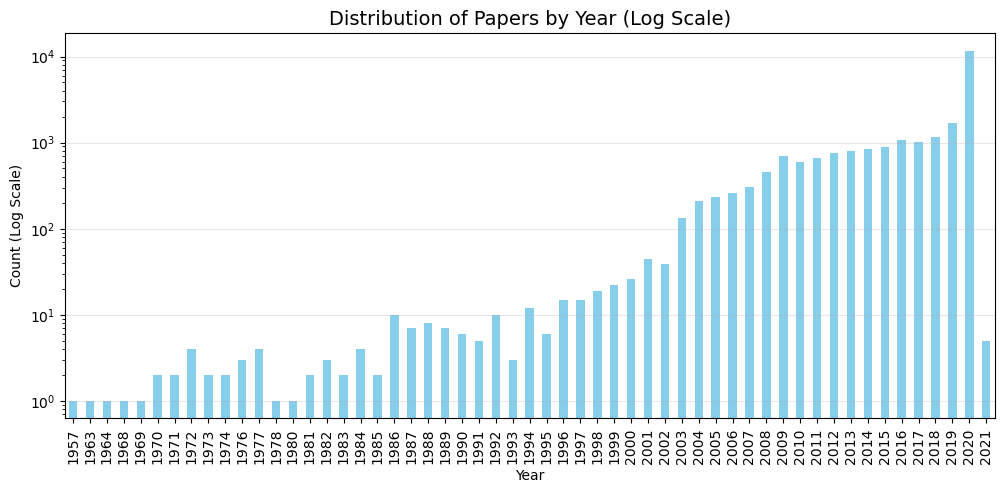

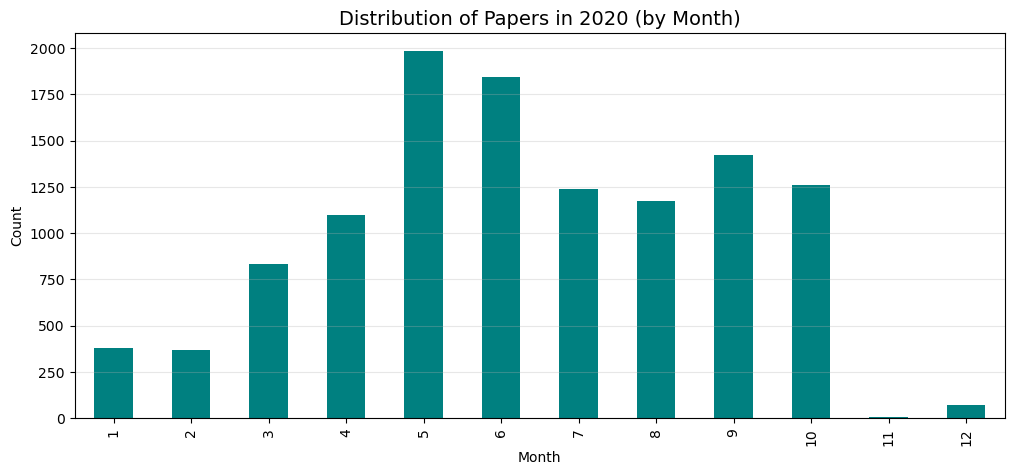

In [4]:
# --- Timeline Analysis (Deciding the Filter) ---
print("\n--- Date Distribution Analysis ---")

# Convert to datetime, coerce errors to NaT
final_df['publish_date'] = pd.to_datetime(final_df['publish_time'], errors='coerce')

# Count how many have NO date
missing_dates = final_df['publish_date'].isnull().sum()
print(f"Papers with Missing/Invalid Dates: {missing_dates} ({(missing_dates/len(final_df))*100:.1f}%)")

# Plot Yearly Distribution (Log scale to see pre-2020 data)
plt.figure(figsize=(12, 5))
final_df['publish_date'].dt.year.value_counts().sort_index().plot(kind='bar', color='skyblue', logy=True)
plt.title('Distribution of Papers by Year (Log Scale)', fontsize=14)
plt.ylabel('Count (Log Scale)')
plt.xlabel('Year')
plt.grid(axis='y', alpha=0.3)
plt.show()

# Plot Monthly Distribution for 2020 (The Core Data)
data_2020 = final_df[final_df['publish_date'].dt.year == 2020]
plt.figure(figsize=(12, 5))
data_2020['publish_date'].dt.month.value_counts().sort_index().plot(kind='bar', color='teal')
plt.title('Distribution of Papers in 2020 (by Month)', fontsize=14)
plt.xlabel('Month')
plt.ylabel('Count')
plt.grid(axis='y', alpha=0.3)
plt.show()

---
 **3.** Year-by-Year Breakdown: By aggregating paper counts by year, we assess the volume disparity. If 50% of the dataset predates 2019, a single topic model might bifurcate into "Old Science" vs. "New Science," diluting the granularity of the COVID-19 topics.

---

In [5]:
# Ensure date column is ready
final_df['publish_date'] = pd.to_datetime(final_df['publish_time'], errors='coerce')
final_df['year'] = final_df['publish_date'].dt.year

print("--- Year-by-Year Breakdown ---")
# Count papers per year
year_counts = final_df['year'].value_counts().sort_index()

# Print specifically:
print(f"Total Papers: {len(final_df)}")
print(f"Pre-2019 Papers: {year_counts[year_counts < 2019].sum()}")
print(f"2019 Papers: {year_counts.get(2019, 0)}")
print(f"2020 Papers: {year_counts.get(2020, 0)}")
print(f"2021 Papers: {year_counts.get(2021, 0)}")

print("\n--- Detailed Look at 2000-2019 (The Historical Block) ---")
# Print the counts for the last 20 years to see if there's a SARS (2003) spike
print(year_counts.loc[2000:2019])

print("\n--- Detailed Look at 2020 (The Pandemic) ---")
# Breakdown 2020 by month to ensure we have the 'waves'
df_2020 = final_df[final_df['year'] == 2020]
month_counts = df_2020['publish_date'].dt.month.value_counts().sort_index()
print(month_counts)

--- Year-by-Year Breakdown ---
Total Papers: 23693
Pre-2019 Papers: 12021
2019 Papers: 1668
2020 Papers: 11672
2021 Papers: 5

--- Detailed Look at 2000-2019 (The Historical Block) ---
year
2000      26
2001      44
2002      39
2003     133
2004     209
2005     230
2006     256
2007     303
2008     449
2009     701
2010     587
2011     667
2012     765
2013     789
2014     849
2015     882
2016    1061
2017    1018
2018    1156
2019    1668
Name: count, dtype: int64

--- Detailed Look at 2020 (The Pandemic) ---
publish_date
1      380
2      369
3      831
4     1098
5     1983
6     1846
7     1238
8     1172
9     1420
10    1261
11       3
12      71
Name: count, dtype: int64


---
 **4.** Temporal Filtering Decision: Based on the review, we apply a strict date filter (>= Dec 2019). This transforms the dataset from a general "Coronavirus History" corpus into a specific "COVID-19 Pandemic" corpus, allowing for fine-grained monthly analysis.

---

In [6]:
# 1. Temporal Filter (Focus on the Pandemic)
print(" Applying Date Filter (Dec 2019 - Oct 2020)...")
# We select papers from Dec 2019 onwards
df = final_df[final_df['publish_time'] >= '2019-12-01'].copy()
print(f"Original Count: {len(final_df)} -> Pandemic Era Count: {len(df)}")

 Applying Date Filter (Dec 2019 - Oct 2020)...
Original Count: 23693 -> Pandemic Era Count: 11826


---
 **5.** Text Analysis (Length): We analyze the word count distribution of the full text. Papers with extremely low word counts (< 50 words) are often metadata errors, retractions, or empty placeholders. These must be purged to prevent the model from learning "empty" topics.

---


--- Text Analysis ---
count     11826.000000
mean       3834.363267
std        3979.181060
min           4.000000
25%        1675.250000
50%        3315.500000
75%        5018.000000
max      154929.000000
Name: word_count, dtype: float64


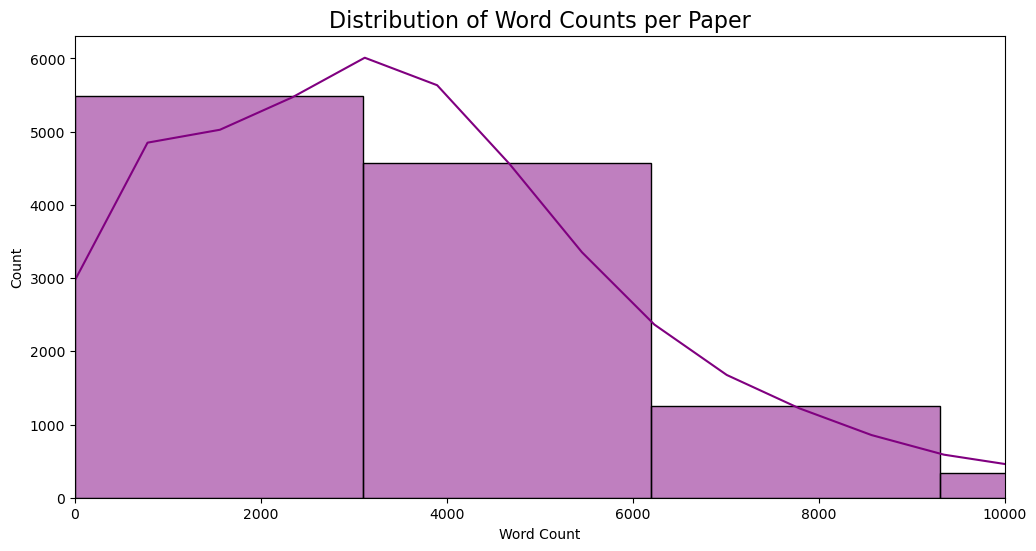

In [7]:
# ---  Text Analysis (Checking Topic Model Feasibility) ---
print("\n--- Text Analysis ---")

# Calculate word counts (approximate by splitting on space)
# We use the 'full_text' column we created
df['word_count'] = df['full_text'].apply(lambda x: len(str(x).split()))

# Basic Stats
print(df['word_count'].describe())

# Plot Word Count Distribution
plt.figure(figsize=(12, 6))
sns.histplot(df['word_count'], bins=50, kde=True, color='purple')
plt.title('Distribution of Word Counts per Paper', fontsize=16)
plt.xlabel('Word Count')
plt.xlim(0, 10000) # Cap at 10k to see the main distribution clearly
plt.show()

---
 **6.** Vocabulary Analysis (Zipf's Law): Finally, we inspect the frequency distribution of the entire vocabulary. We look for Stop Words (words appearing in >95% of docs, like "study" or "data") and Rare Words (words appearing <10 times). This statistical profile helps set the parameters for our Dictionary creation step.

---

--- Vocabulary Analysis (Preparing for LDA) ---
Total Unique Words (Vocabulary Size): 149429
Top 10 Most Frequent Words: ['usepackage', 'document', 'end', 'begin', 'minimal', '12pt', 'documentclass', 'amsmath', 'wasysym', 'amsfonts']
Words appearing fewer than 10 times: 83311 (55.8%)


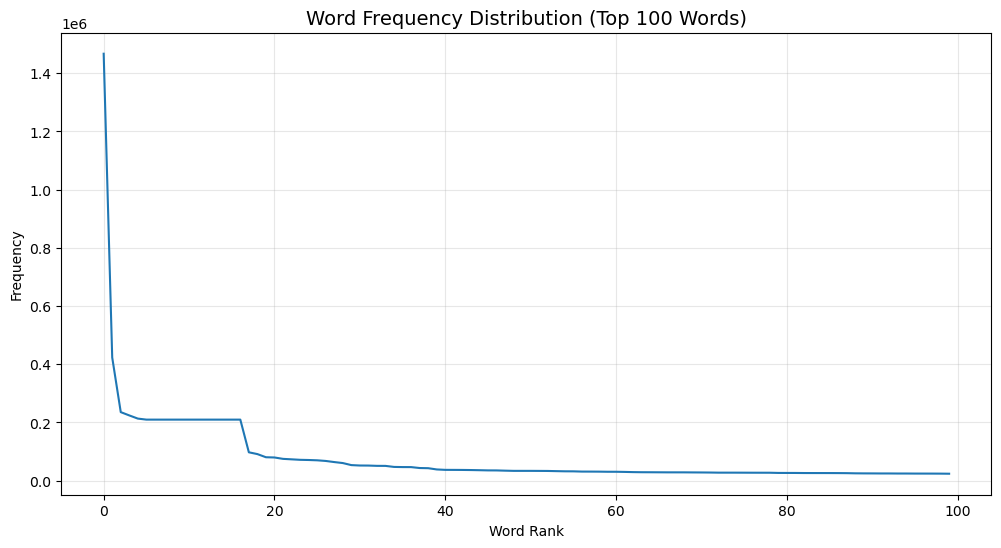

In [8]:
print("--- Vocabulary Analysis (Preparing for LDA) ---")

# 1. Create a basic vectorizer (just to count words)
# We use a sample if the dataset is huge, but for 23k papers, we can run it on all.
# We look at words (unigrams)
cv = CountVectorizer(stop_words='english', min_df=2, max_df=0.95)
data_cv = cv.fit_transform(df['full_text'].dropna())

# 2. Calculate Word Frequencies
sum_words = data_cv.sum(axis=0) 
words_freq = [(word, sum_words[0, idx]) for word, idx in cv.vocabulary_.items()]
words_freq = sorted(words_freq, key = lambda x: x[1], reverse=True)

# 3. Print Stats
total_vocab_size = len(cv.vocabulary_)
print(f"Total Unique Words (Vocabulary Size): {total_vocab_size}")
print(f"Top 10 Most Frequent Words: {[w[0] for w in words_freq[:10]]}")

# 4. Check for "Rare" Words (The Long Tail)
# Words that appear less than 10 times usually add noise to LDA
rare_threshold = 10
rare_count = sum(1 for w in words_freq if w[1] < rare_threshold)
print(f"Words appearing fewer than {rare_threshold} times: {rare_count} ({(rare_count/total_vocab_size)*100:.1f}%)")

# 5. Visualizing the Distribution (Zipf's Law check)
# We plot the frequency of the top 100 words
top_100_counts = [w[1] for w in words_freq[:100]]
plt.figure(figsize=(12, 6))
plt.plot(top_100_counts)
plt.title('Word Frequency Distribution (Top 100 Words)', fontsize=14)
plt.xlabel('Word Rank')
plt.ylabel('Frequency')
plt.grid(True, alpha=0.3)
plt.show()

## NLP Preprocessing Pipeline
 
 Data quality is the ceiling of model performance. Scientific texts present unique challenges that standard NLP libraries (like NLTK) cannot handle out of the box. To maintain code cleanliness and reproducibility, we have encapsulated our cleaning logic into a modular Python script: cord19_preprocessing.py.
 
 ### The Cleaning Strategy:
 
* **Noise Removal (Regex):** We strip non-semantic elements such as URLs, email addresses, and specific LaTeX formatting tags (e.g., \usepackage, {12pt}). Our EDA revealed that without this step, "LaTeX Syntax" becomes a dominant topic in the model.
    
* **Scientific Stopword Removal:** Standard English stopwords ("the", "and") are insufficient. We implemented a custom "Domain-Specific Stopword List" to remove generic academic boilerplate, such as "copyright," "peer-reviewed," "submitted," "methodology," and "conclusion." These words appear in every paper but distinguish none.
    
* **Lemmatization (Spacy):** We utilize en_core_web_sm to reduce words to their root forms (e.g., "viruses," "viral," and "virion"→"virus"). This reduces the dimensionality of the vector space.
    
* **Phrase Detection (Gensim):** Using a statistical collocation model, we detect and conjoin Bigrams. This is crucial for medical accuracy; ensuring that "Public Health" is treated as the distinct concept public_health rather than the separate tokens public and health.


 The output of this pipeline is a serialized corpus of tokenized, bigram-enriched documents, ready for vectorization.

In [ ]:
import spacy
from gensim.models.phrases import Phrases, Phraser
from tqdm import tqdm
import cord19_preprocessing as nlp

# Run filters, regex, spacy, and bigrams
df_clean = nlp.run_nlp_pipeline(df)

# Save as Pickle (Preserves the list structure)
df_clean.to_pickle("cord19_ready_for_models.pkl")
print("Saved to 'cord19_ready_for_models.pkl'")

Filtering for Pandemic Era (Dec 2019+)...
Removing short documents...
Documents remaining: 11651
Applying Regex Cleaning...


100%|██████████| 11651/11651 [00:48<00:00, 238.88it/s]


Tokenizing & Lemmatizing (This takes time)...


100%|██████████| 11651/11651 [1:01:07<00:00,  3.18it/s]


Building Bigrams...


100%|██████████| 11651/11651 [00:23<00:00, 489.66it/s]


Preprocessing Complete.


In [2]:
#  Instead of processing the dataset simple load it here for the rest of the project
# Load the data for the LDA step
df_clean = pd.read_pickle("cord19_ready_for_models.pkl")
df_clean

,cord_uid,publish_time,title,abstract,full_text,publish_date,year,word_count,clean_text,tokens,tokens_bigram
4351,p58n51xv,2019-12-22,Characterisation of Crandell-Rees Feline Kidne...,The Crandell-Rees Feline Kidney Cell (CRFK) is...,Characterisation of Crandell-Rees Feline Kidne...,2019-12-22,2019,1197,characterisation of crandellrees feline kidney...,"[characterisation, crandellree, feline, kidney...","[characterisation, crandellree, feline_kidney,..."
4360,heo6mtxk,2019-12-22,Half-Life of African Swine Fever Virus in Ship...,African swine fever virus is transmissible thr...,Half-Life of African Swine Fever Virus in Ship...,2019-12-22,2019,994,halflife of african swine fever virus in shipp...,"[halflife, african, swine, fever, ship, feed, ...","[halflife, african_swine, fever, ship, feed, a..."
4375,4tt0vnr4,2019-12-02,CXCR6 regulates localization of tissue-residen...,Resident memory T cells (T(RM) cells) are an i...,CXCR6 regulates localization of tissue-residen...,2019-12-02,2019,7237,cxcr regulates localization of tissueresident ...,"[cxcr, regulate, localization, tissueresident,...","[cxcr, regulate, localization, tissueresident_..."
4379,9c0zrp7p,2019-12-03,Local risk perception enhances epidemic control,"As infectious disease outbreaks emerge, public...",Local risk perception enhances epidemic contro...,2019-12-03,2019,3878,local risk perception enhances epidemic contro...,"[local, risk, perception, enhance, epidemic, c...","[local, risk_perception, enhance, epidemic, co..."
4381,iaktm72a,2019-12-03,Curcumin to Promote the Synthesis of Silver NP...,This work presents a simple one-pot protocol t...,Curcumin to Promote the Synthesis of Silver NP...,2019-12-03,2019,5929,curcumin to promote the synthesis of silver np...,"[curcumin, promote, synthesis, silver, selfass...","[curcumin, promote, synthesis, silver, selfass..."
...,...,...,...,...,...,...,...,...,...,...,...
12308,8igfuaw2,2020-06-15,PROTECTIVE ANTIBODIES AGAINST HPIV3 INFECTION,Human parainfluenza virus type III (HPIV3) is ...,PROTECTIVE ANTIBODIES AGAINST HPIV3 INFECTION ...,2020-06-15,2020,6242,protective antibodies against hpiv infection h...,"[protective, antibody, hpiv, infection, human,...","[protective, antibody, hpiv, infection, human_..."
12310,hjtq6wvv,2020-09-09,Regeneration of lung epithelial cells by Fulle...,Acute respiratory distress syndrome (ARDS) inv...,Regeneration of lung epithelial cells by Fulle...,2020-09-09,2020,1564,regeneration of lung epithelial cells by fulle...,"[regeneration, lung, epithelial, cell, fullere...","[regeneration, lung_epithelial, cell, fulleren..."
12311,d55wjar0,2020-08-24,Physical Activity for Oncological Patients in ...,Whereas the coronavirus disease (COVID-19) sto...,Physical Activity for Oncological Patients in ...,2020-08-24,2020,2955,physical activity for oncological patients in ...,"[physical, activity, oncological, patient, cov...","[physical_activity, oncological, patient, covi..."
12316,2ss1ypgr,2020-08-29,Two sorts of microthrombi in a COVID-19 patien...,NaN,Two sorts of microthrombi in a COVID-19 patien...,2020-08-29,2020,377,two sorts of microthrombi in a covid patient w...,"[sort, microthrombi, covid, patient, lung, can...","[sort, microthrombi, covid, patient, lung_canc..."


## Dictionary & Probabilistic Modeling: Latent Dirichlet Allocation (LDA)
 With the text cleaned, we move to the core modeling phase. LDA is a generative probabilistic model that assumes every document is a mixture of topics, and every topic is a mixture of words.
 
 **1.** Vocabulary Optimization (cord19_dictionary.py): We construct a Gensim Dictionary, mapping unique tokens to integer IDs. However, raw vocabularies follow a power law (Zipf's Law) where most words are noise. We apply statistical filtering:
* **no_below=20:** We prune tokens appearing in fewer than 20 documents. These are likely typos, unique variables, or highly specific chemical  names that cannot form a cluster.
* **no_above=0.35:** We prune tokens appearing in more than 35% of the corpus. Words like "patient," "disease," and "infection" are too ubiquitous to help differentiate topics.

In [4]:
import cord19_dictionary as c_dict
import cord19_lda as c_lda

# Select the specific column containing the tokens
tokens = df_clean['tokens_bigram']

# Check stats before building
_ = c_dict.analyze_vocabulary(tokens)

#  Build Dictionary & Corpus
# Create the artifacts (This handles German stopwords + filters)
id2word, corpus = c_dict.create_dictionary_corpus(tokens, no_below=20, no_above=0.35)

--- 1. Initial Dictionary Build ---
Total Documents: 11651
Total Unique Words: 508459

--- Rare Word Analysis (Bottom End) ---
Words appearing in < 5 docs: 420828 (82.8%)
Words appearing in < 10 docs: 452142 (88.9%)
Words appearing in < 20 docs: 476006 (93.6%)
Words appearing in < 50 docs: 493371 (97.0%)

--- 2. Building Final Dictionary/Corpus ---
Original Vocabulary Size: 508459
Removed 23 German stopwords.
Vocabulary Size after Filtering: 32258
Dictionary and Corpus saved to disk.

Top 20 Most Frequent Words in Corpus:
cell: 46175
protein: 27628
network: 23107
country: 21735
algorithm: 21364
parameter: 21321
sequence: 20336
activity: 20217
health: 19916
people: 19068
user: 18860
estimate: 18427
clinical: 17738
variable: 17481
region: 17031
day: 16818
student: 16648
gene: 16589
participant: 16390
solution: 16363


---
 **2.** Hyperparameter Tuning (cord19_lda.py)
 
Choosing the number of topics (K) is the most difficult decision in LDA.
    
* Too few topics (K=5): Topics become broad and muddled (e.g., mixing "Ventilators" with "Hospital Administration").
* Too many topics (K=50): Topics become fragmented and repetitive.

**The Solution:** We implement an optimization loop, training multiple models with K ranging from 5 to 30. We evaluate each model using the Coherence Score, which measures the semantic similarity between the top words in a topic.
 
**Result:** Our tuning process identified K=25 as the optimal structure, yielding a Coherence Score of 0.64. This configuration minimizes overlap while achieving high granularity, successfully separating subtle domains like "Bacterial Co-infection" from "Viral Pneumonia."

---

Starting Hyperparameter Tuning on 11651 documents...
Coherence: 0.6031th 5 topics... 
Coherence: 0.5759th 10 topics... 
Coherence: 0.6278th 15 topics... 
Coherence: 0.6247th 20 topics... 
Coherence: 0.6451th 25 topics... 
Coherence: 0.6333th 30 topics... 


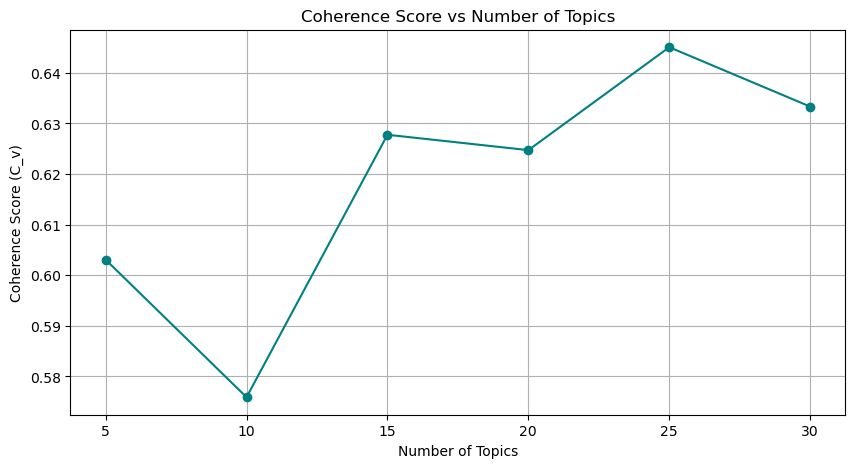


Winner: 25 Topics with Score: 0.6451
Optimal model saved as 'lda_optimal_25.model'

--- FULL TOPIC LIST ---
[(0,
  '0.047*"protein" + 0.031*"interaction" + 0.026*"bind" + 0.023*"drug" + '
  '0.017*"residue" + 0.017*"molecule" + 0.016*"compound" + 0.016*"complex" + '
  '0.011*"inhibitor" + 0.011*"domain"'),
 (1,
  '0.037*"pathogen" + 0.033*"antibiotic" + 0.029*"bacteria" + '
  '0.023*"resistance" + 0.022*"bacterial" + 0.019*"strain" + 0.016*"organism" '
  '+ 0.014*"skin" + 0.014*"culture" + 0.012*"pneumonia"'),
 (2,
  '0.039*"symptom" + 0.015*"drug" + 0.015*"severe" + 0.013*"therapy" + '
  '0.011*"syndrome" + 0.010*"clinical" + 0.010*"diagnosis" + 0.009*"day" + '
  '0.009*"treat" + 0.009*"month"'),
 (3,
  '0.018*"surgery" + 0.015*"lung" + 0.011*"normal" + 0.010*"image" + '
  '0.009*"diagnosis" + 0.009*"tumor" + 0.009*"surgical" + 0.008*"pneumonia" + '
  '0.008*"imaging" + 0.008*"procedure"'),
 (4,
  '0.016*"dataset" + 0.015*"image" + 0.013*"algorithm" + 0.013*"user" + '
  '0.012*"netwo

In [5]:
# Run the training loop (5 to 30 topics)
results = c_lda.run_optimization_loop(id2word, corpus, tokens, start=5, limit=31, step=5)

# Plot the graph
c_lda.plot_coherence(results)

# Automatically pick and save the best one
best_model = c_lda.save_best_model(results)

## Semantic Interpretation & Temporal Analysis
        
 A topic model outputs lists of probabilities, not answers. The final phase of the Probabilistic pipeline involves interpreting these mathematical clusters and mapping them back to the timeline:
 
 **1.** The "Dominant Topic" Heuristic: LDA assigns every paper a probability distribution across all 25 topics (e.g., 10% Topic A, 85% Topic B, 5% Topic C). To facilitate time-series plotting, we assign each paper to its single Dominant Topic (the one with the highest probability). This effectively turns an unsupervised clustering problem into a "labeled" dataset.

In [6]:
import pyLDAvis
import pyLDAvis.gensim_models as gensimvis

print("Preparing pyLDAvis visualization...")

# 1. Prepare the Visualization
# This calculates the distance between topics and their keywords
# Note: Use lda_final (or whatever variable holds your 25-topic model)

# If loaded it from disk: 
#best_model = gensim.models.LdaModel.load("lda_optimal_25.model")

pyLDAvis.enable_notebook()
vis_data = gensimvis.prepare(best_model, corpus, id2word)

# 2. Save as HTML 
pyLDAvis.save_html(vis_data, 'lda_25_topics_visualization.html')
print("Visualization saved as 'lda_25_topics_visualization.html'. ")

Preparing pyLDAvis visualization...
Visualization saved as 'lda_25_topics_visualization.html'. 


---
 **2.** Human-in-the-Loop Labeling:

 We manually inspected the top keywords for all 25 topics to assign professional scientific labels.
* **Example:** A topic containing mask, aerosol, surface, transmission was labeled "Environmental Transmission."
* **Example:** A topic containing anxiety, stress, mental, survey was labeled "Mental Health/Social Impact."

---

In [7]:
from topic_modeling_utils import assign_dominant_topics, TOPIC_LABEL_MAP

# You can also view the imported map if you need to
print("Imported Topic Labels:")
print(TOPIC_LABEL_MAP)

# Call the function to get the final DataFrame
print("\nAssigning topics to documents...")
df_dominant = assign_dominant_topics(ldamodel=best_model, corpus=corpus, original_df=df_clean)

# Display the results
# The function already prints the shape, so we can just display the head
print("\nPreview of the final DataFrame:")
print(df_dominant[['publish_time', 'Dominant_Topic', 'Topic_Label', 'Topic_Keywords']].head())

Imported Topic Labels:
{0: 'Biochem/Protein Interaction', 1: 'Bacterial/Antibiotics', 2: 'Clinical Symptoms', 3: 'Surgery & Radiology', 4: 'AI/Deep Learning', 5: 'Sensors/Physics', 6: 'Diagnostic Testing', 7: 'Vaccine/Immunology', 8: 'Ventilators/Respiratory Failure', 9: 'Cellular Biology', 10: 'Genomics/Viral Evolution', 11: 'Clinical Mortality/Risk Factors', 12: 'Neuro/Pathway Mechanisms', 13: 'Govt Policy/Economy', 14: 'Social Context/Community', 15: 'Pediatrics/Family Health', 16: 'Epidemiology/Spread', 17: 'Math Modeling/Simulation', 18: 'Education/Surveys', 19: 'Environmental/Urban', 20: 'Lab Assays/Protocols', 21: 'Literature Review', 22: 'Statistical Forecasting', 23: 'Healthcare Services', 24: 'General Virology'}

Assigning topics to documents...
Topic assignment complete. New DataFrame shape: (11651, 15)

Preview of the final DataFrame:
  publish_time  Dominant_Topic               Topic_Label  \
0   2019-12-22               9          Cellular Biology   
1   2019-12-22       

---
 **3.** The Evolution of Science (Time Series):
 By aggregating these labeled papers by publication month, we visualize the "Story Arcs" of the pandemic. This analysis reveals the reactive nature of the scientific community:
* **The "AI Spike":** We observe an immediate surge in Computer Science/AI papers in early 2020. Lacking biological samples, researchers relied on available X-Ray/CT datasets to build diagnostic models.
* **The "Clinical Crisis":** Research into Ventilators and Respiratory Care peaks in April/May 2020, aligning with the first wave of hospitalizations.
* **The "Long Game":** Topics related to Vaccines and Education show a slower, steady growth, dominating the discourse in late 2020 as the focus shifted from immediate survival to long-term solutions.

---

<Figure size 1400x800 with 0 Axes>

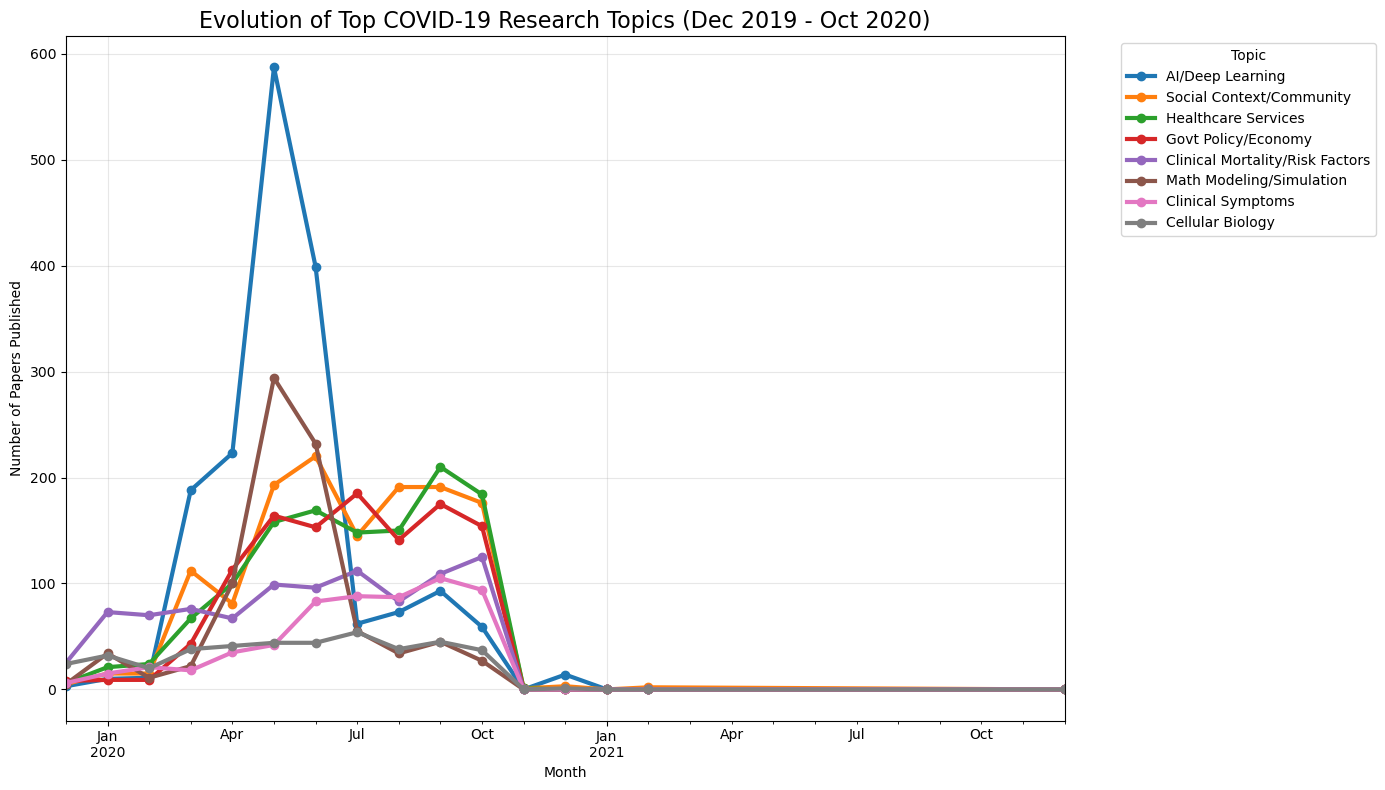

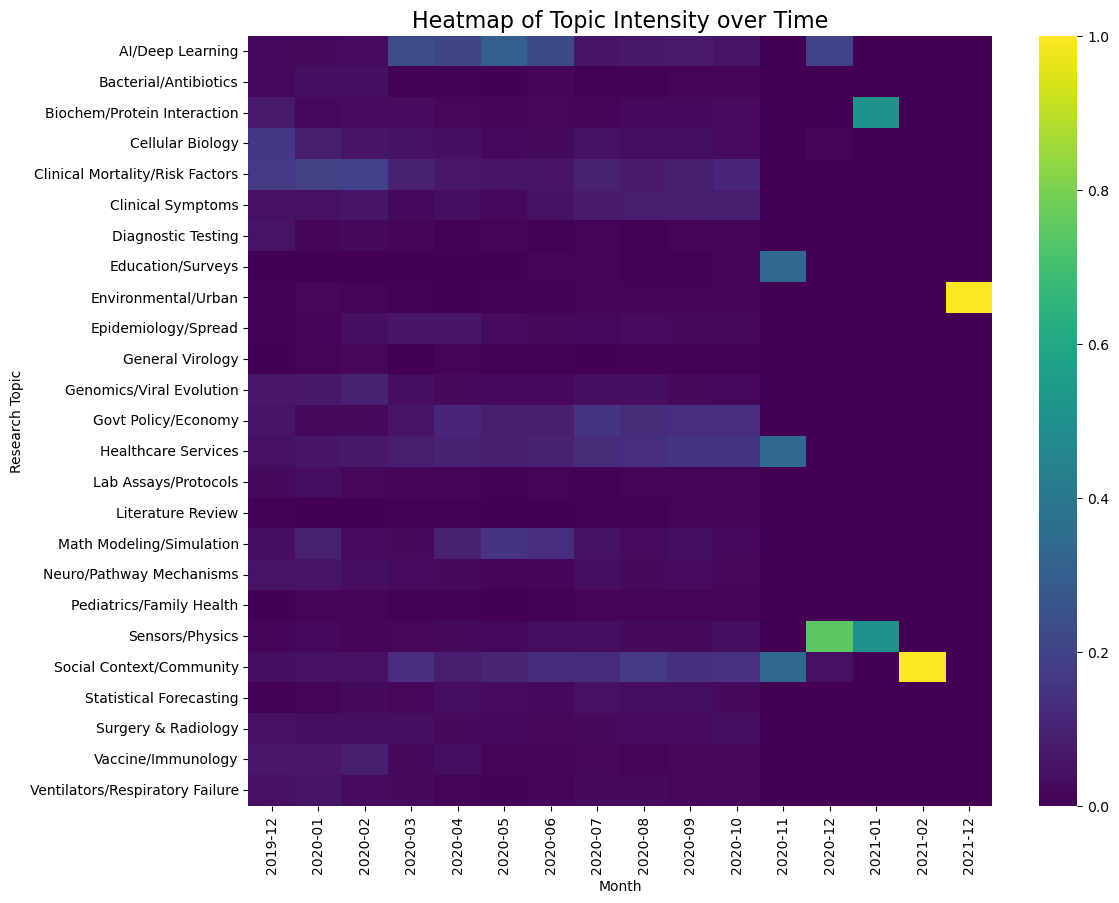

In [8]:
#  Visualize the Evolution (Time Series)
# We will create two plots:
#  1) Topic Volume: How many papers per month?
#  2) Topic Heatmap: Seeing the intensity over time.

# 1. Prepare Time Data
df_dominant['publish_time'] = pd.to_datetime(df_dominant['publish_time'])
# Create a "Month-Year" column for aggregation (e.g., 2020-04)
df_dominant['Month'] = df_dominant['publish_time'].dt.to_period('M')

# 2. Aggregate
# Count papers per Topic per Month
topic_counts = df_dominant.groupby(['Month', 'Topic_Label']).size().reset_index(name='Count')

# Pivot for plotting (Rows=Month, Cols=Topic, Values=Count)
topic_matrix = topic_counts.pivot(index='Month', columns='Topic_Label', values='Count').fillna(0)

# Filter: Let's plot only the Top 8 most popular topics to keep the chart readable
top_topics = df_dominant['Topic_Label'].value_counts().head(8).index
subset_matrix = topic_matrix[top_topics]

# 3. Plot 1: Line Chart of Top Topics
plt.figure(figsize=(14, 8))
subset_matrix.plot(kind='line', linewidth=3, figsize=(14, 8), marker='o')
plt.title('Evolution of Top COVID-19 Research Topics (Dec 2019 - Oct 2020)', fontsize=16)
plt.xlabel('Month')
plt.ylabel('Number of Papers Published')
plt.legend(title='Topic', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# 4. Plot 2: The Heatmap (Shows ALL 25 topics)
# Normalize by month (Percentage of papers that month)
# This shows "Focus Shift" rather than just volume
topic_pct = topic_matrix.div(topic_matrix.sum(axis=1), axis=0)

plt.figure(figsize=(12, 10))
sns.heatmap(topic_pct.T, cmap='viridis', annot=False)
plt.title('Heatmap of Topic Intensity over Time', fontsize=16)
plt.xlabel('Month')
plt.ylabel('Research Topic')
plt.show()

## Semantic Modeling: BERTopic & SPECTER
 While LDA provides a robust high-level overview, it suffers from the "Bag of Words" limitation—it assumes that documents are similar only if they share the exact same words. In scientific literature, where terminology evolves rapidly (e.g., "2019-nCoV" becoming "SARS-CoV-2"), this can lead to fragmented topics. To address this, we implement BERTopic, a topic modeling technique that leverages transformers and class-based TF-IDF.
 
We diverge from the standard BERTopic implementation in one critical aspect: Embeddings.
* Standard BERT: Trained on general text (Wikipedia, Reddit). It understands English, but not Science.
* Our Choice (AllenAI SPECTER): We utilize SPECTER embeddings. This model is pre-trained specifically on scientific citations. It understands that if Paper A cites Paper B, they are semantically related, even if they use different vocabulary. This allows the model to cluster papers based on intellectual lineage rather than just keyword frequency.

**The Pipeline:**
    
* **Embeddings**: Documents are converted into dense vector representations using SPECTER.
* **Dimensionality Reduction (UMAP)**: The high-dimensional vectors are compressed to 5 dimensions to reveal local structures.
* **Clustering (HDBSCAN)**: A density-based clustering algorithm identifies the core topics and isolates outliers (noise), ensuring that the resulting topics consist only of highly related papers.

In [1]:
from bertopic import BERTopic
import cord19_bertopic as bert_module

# 1. Prepare Data
# Use 'clean_text' (Regex processed) for better embedding quality than raw full_text
docs = df_clean['clean_text'].tolist()
timestamps = df_clean['publish_time'].tolist()

# 2. Train Model
# This handles the SPECTER embedding and KeyBERT representation automatically
topic_model, embeddings = bert_module.train_scientific_bertopic(docs)

# Save the Model and Embeddings (Highly Recommended!)
print("\n--- Saving Model and Embeddings ---")
topic_model.save("cord19_specter_model")
np.save("cord19_specter_embeddings.npy", embeddings)
print("Save Complete.")

# 3. View Topics
print(topic_model.get_topic_info().head(10))

# 4. Run Time Series
topics_over_time = bert_module.run_temporal_analysis(topic_model, docs, timestamps)

# 5. Visualize
topic_model.visualize_topics_over_time(topics_over_time, top_n_topics=10)


KeyboardInterrupt



## Model Evaluation: Coherence vs. Granularity

To compare the Probabilistic approach **(LDA)** with the Semantic approach **(BERTopic)**, subjective inspection is not enough. We must quantify the quality of the topics. We employ the Coherence Score, the same metric used to tune our LDA model.
* **The Evaluation Challenge**: BERTopic does not natively output a coherence score because it optimizes for cluster density in vector space, not word co-occurrence. To bridge this gap, we extract the top 20 keywords from every BERTopic cluster and feed them back into the Gensim Coherence pipeline using our original tokenized corpus.
    
**Interpreting the Comparison:** 
    
* **LDA (The Baseline)**: Optimized directly for Coherence. We expect a high score (~0.60+), indicating that the top words in each topic frequently appear together.
* **BERTopic (The Challenger)**: Optimized for Semantic Meaning. We may see a slightly lower Coherence score, but this is often a trade-off for Higher Granularity.

**Hypothesis:**
 
 While LDA groups "Bacteria" into one topic, BERTopic is expected to find specific pathogens (e.g., Acinetobacter, Staphylococcus) that represent distinct clinical challenges. If BERTopic achieves a competitive Coherence score (>0.50) while offering significantly higher granularity (100+ topics vs. 25), it serves as the superior tool for specific information retrieval, while LDA remains the superior tool for broad document routing.

In [ ]:
from bertopic import BERTopic
import cord19_bertopic as bert_module
import cord19_bertopic_eval as bert_eval

print("Loading saved BERTopic model...")
# Load the model structure
topic_model = BERTopic.load("cord19_specter_model")

# Load the embeddings (Optional for Coherence, but good to have if you want to visualize again)
embeddings = np.load("cord19_specter_embeddings.npy") 

print("Model loaded successfully.")
# 1. Calculate Coherence
# We pass the trained model AND the original tokenized data
cv_score_bert = bert_eval.calculate_bertopic_coherence(topic_model, df_clean['tokens_bigram'], top_n_words=20)

# 2. Compare with LDA 
lda_score = 0.6451 
print("\n--- FINAL MODEL COMPARISON ---")
print(f"LDA Coherence (Cv):      {lda_score:.4f}")
print(f"BERTopic Coherence (Cv): {cv_score_bert:.4f}")

if cv_score_bert > lda_score:
    print("Winner: BERTopic is both semantically rich and highly coherent.")
else:
    print("Winner: LDA has higher coherence (expected), but BERTopic offers better granularity.")

--- Topic Summary ---


,Topic,Count,Name,Representation,Representative_Docs
0,-1,3991,-1_clinical_covid_care_in,"[clinical, covid, care, in, infection, cells, ...",[will the world ever be the same after covid t...
1,0,727,0_ventilator_sepsis_care_hospital,"[ventilator, sepsis, care, hospital, mortality...",[abstracts of the th annual conference of iact...
2,1,560,1_covid_figure_infection_in,"[covid, figure, infection, in, disease, this, ...",[semiparametric bayesian inference for the tra...
3,2,372,2_network_graph_in_node,"[network, graph, in, node, number, nodes, this...",[learning to rank images with crossmodal graph...
4,3,341,3_this_in_time_how,"[this, in, time, how, other, different, new, m...",[covid remote learning transition in spring cl...
...,...,...,...,...,...
96,95,16,95_clinical_care_patients_patient,"[clinical, care, patients, patient, treatment,...",[the empowersustain ehealth intervention to im...
97,96,15,96_tree_flowbased_in_tools,"[tree, flowbased, in, tools, graph, variable, ...",[sequoia a playground for logicians system des...
98,97,15,97_triage_patient_covid_care,"[triage, patient, covid, care, patients, hospi...",[ethical legal and social challenges in the de...
99,98,15,98_covid_treatment_patients_hiv,"[covid, treatment, patients, hiv, lysozyme, in...",[blocking of the cd axis as a therapeutic appr...



Found a total of 100 topics (excluding outliers).


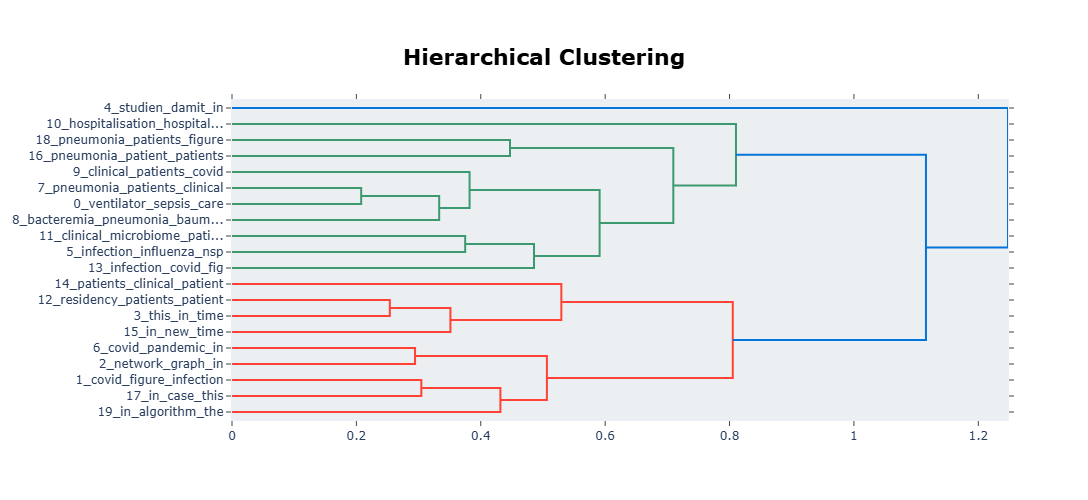

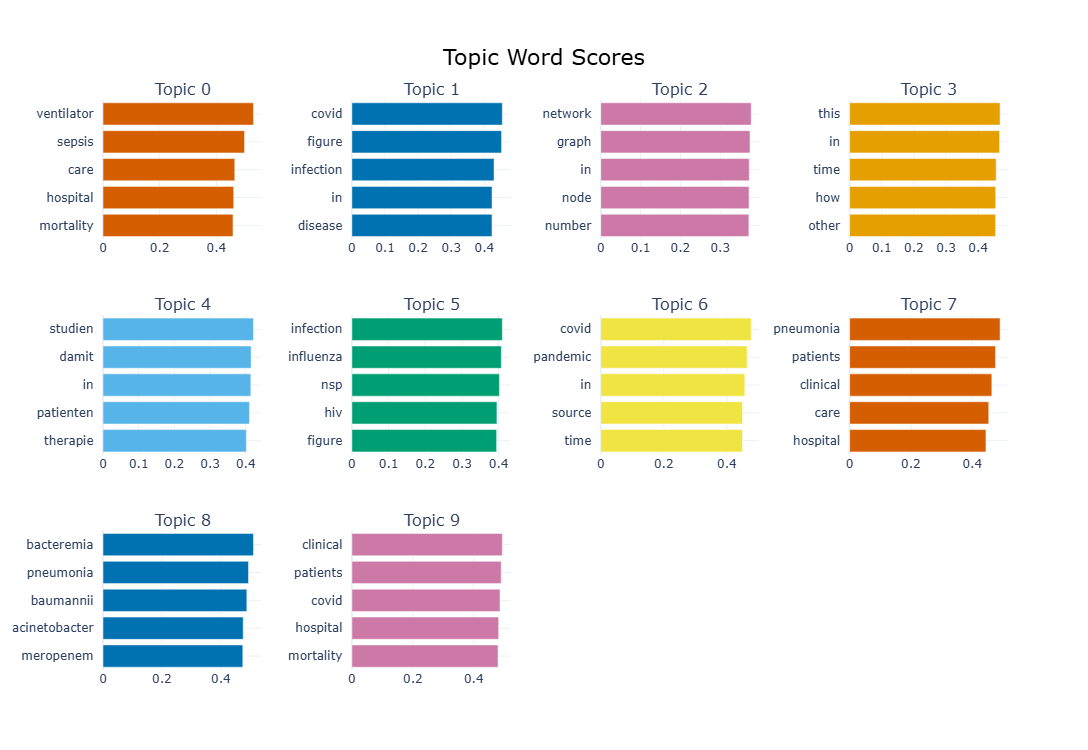

In [7]:
# Use display() for a cleaner table in Jupyter
print("--- Topic Summary ---")
display(topic_model.get_topic_info())

# You can also get the total number of topics found
topic_count = len(topic_model.get_topic_info()) -1 # Subtract 1 for the outlier topic
print(f"\nFound a total of {topic_count} topics (excluding outliers).")

# 1. Visualize the Hierarchy
# This proves that BERTopic found structure (e.g., grouping specific virus types together)
# that LDA missed.
fig_tree = topic_model.visualize_hierarchy(top_n_topics=20)
fig_tree.show()

# 2. Visualize the Barchart
# This shows how clean the keywords are compared to LDA.
fig_bar = topic_model.visualize_barchart(top_n_topics=10)
fig_bar.show()

---
## Final Conclusion: LDA vs. BERTopic
This project explored the evolution of COVID-19 research using two distinct unsupervised learning techniques. Both models successfully identified the major phases of the pandemic, but the quantitative evaluation reveals a distinct trade-off between coherence and granularity.
 
 1. **Latent Dirichlet Allocation (LDA)**, Coherence Score: 0.6451 (High)
    * LDA achieved a high coherence score, indicating strong word co-occurrence within topics. It excelled at identifying broad, distinct disciplines (e.g., distinguishing "Math Modeling" from "Clinical Care").
    * With only 25 topics, it lacked the resolution to identify specific sub-problems (e.g., specific hospital-acquired infections).

 2. **BERTopic (with SPECTER Embeddings)**, Coherence Score: 0.4009 (Moderate)
    * Despite a lower coherence score (typical for embedding-based models that prioritize meaning over exact word matches), BERTopic produced 100 highly granular topics. It successfully distinguished specific pathogens (e.g., Acinetobacter, Norovirus) and nuances in clinical care that LDA grouped together.
    * It automatically isolated non-English papers into a single noise cluster without requiring the extensive manual stopword engineering needed for LDA.

 3. **Temporal Insight**
Both models confirmed a distinct timeline:
    * Q1 2020: Dominated by Deep Learning/AI (Topic 4 in LDA) as researchers relied on X-Rays in the absence of biological data.
    * Q2 2020: A surge in Critical Care/Ventilators (Topic 8 in LDA) as hospitals became overwhelmed.
    * Q3/Q4 2020: A steady rise in Vaccine/Immunology (Topic 7 in LDA), shifting focus from containment to cure.

### Final Verdict:
For this dataset, LDA serves as the superior tool for a summary of the research landscape, while BERTopic is the superior tool for targeted literature review and finding specific answers to niche medical questions.

---

---
## Project Wrap-Up
 
 This project successfully reconstructed the scientific narrative of the early COVID-19 pandemic by applying advanced **Natural Language Processing** to over 11,000 research papers. Through a rigorous comparison of probabilistic (**LDA**) and semantic (**BERTopic**) modeling, we demonstrated that while LDA offers superior statistical coherence (**0.65**) for high-level categorization, BERTopic provides the semantic granularity needed to identify specific medical nuances. Ultimately, the temporal analysis validated the project's hypothesis, accurately visualizing the scientific community's rapid pivot from computational forecasting and crisis management to vaccine development, proving the efficacy of unsupervised learning in synthesizing vast, unstructured datasets.

 ---